In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta, date
import scipy.stats as stats
import yfinance as yf

In [3]:
# Listing down the NSE tickers

TICKERS = [
    'TCS.NS',        'INFY.NS',        'WIPRO.NS',       'HCLTECH.NS',     'TECHM.NS',
    'MPHASIS.NS',    'PERSISTENT.NS',  'HDFCBANK.NS',    'ICICIBANK.NS',   'SBIN.NS',
    'KOTAKBANK.NS',  'AXISBANK.NS',    'BAJFINANCE.NS',  'BAJAJFINSV.NS',  'INDUSINDBK.NS',
    'BANDHANBNK.NS', 'FEDERALBNK.NS',  'HINDUNILVR.NS',  'ITC.NS',         'NESTLEIND.NS',
    'BRITANNIA.NS',  'DABUR.NS',       'MARICO.NS',      'COLPAL.NS',      'MARUTI.NS',
    'M&M.NS',        'BAJAJ-AUTO.NS',  'HEROMOTOCO.NS',  'EICHERMOT.NS',   'SUNPHARMA.NS',
    'DRREDDY.NS',    'CIPLA.NS',       'DIVISLAB.NS',    'APOLLOHOSP.NS',  'RELIANCE.NS',
    'ONGC.NS',       'BPCL.NS',        'IOC.NS',         'TATASTEEL.NS',   'JSWSTEEL.NS',
    'HINDALCO.NS',   'COALINDIA.NS',   'LT.NS',          'ADANIPORTS.NS',  'SIEMENS.NS',
    'BHARTIARTL.NS', 'IDEA.NS',        'ULTRACEMCO.NS'
]

COLORS = {
    "gmv":  "#2563EB",
    "semi": "#DC2626",
    "both": "16A34A"
}

In [4]:
# Getting the data from yfinance and preprocessing it

data = yf.download(
    TICKERS,
    start="2017-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=False,
)

prices = data['Close']

print("- - " * 30)
print("  Data Preprocessing")
print("- - " * 30)

# We will drop any tickers that has more 5% values as NaNs, and we will forward-fill the rest
threshold    = int(0.95 * len(prices))
prices_clean = prices.dropna(axis=1, thresh=threshold).ffill().dropna()

tickers = list(prices_clean.columns)
N       = len(tickers)

# Calculating daily log_returns
R  = np.log(prices_clean / prices_clean.shift(1)).dropna().values
mu = R.mean(axis=0)
T  = R.shape[0]

print(f"  Count of Stocks        : {N}")
print(f"  Count of Trading Days  : {T}")
print(f"  Return Range           : min={mu.min():.5f}  max={mu.max():.5f}")

# Taking 5.53% as risk-free rate of return
RISK_FREE = 0.0553 / 252
print(f"  Risk-free Rate (Daily) : {RISK_FREE:.5f}")

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Data Preprocessing
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Count of Stocks        : 47
  Count of Trading Days  : 2222
  Return Range           : min=-0.00059  max=0.00139
  Risk-free Rate (Daily) : 0.00022


In [5]:
# Building a simple Global Minimum Variance Portfolio

print("- - " * 30)
print("  Global Minimum Variance (GMV) Portfolio")
print("- - " * 30)

Sigma = np.cov(R, rowvar=False)

w_gmv = cp.Variable(N)

prob_gmv = cp.Problem(
    cp.Minimize(cp.quad_form(w_gmv, Sigma)),
    [cp.sum(w_gmv) == 1, w_gmv >=0]
)

prob_gmv.solve(solver=cp.CLARABEL)

if prob_gmv.status not in ("optimal", "optimal_inaccurate"):
  raise RuntimeError(f"GMV solver failed: {prob_gmv.status}")

w_gmv_val  = np.clip(w_gmv.value, 0, None)
w_gmv_val /= w_gmv_val.sum()

print(f"  Solver Status      :  {prob_gmv.status}")
print(f"  Portfolio Variance :  {prob_gmv.value:.8f}")
print(f"  Active Positions   :  {(w_gmv_val > 0.001).sum()} / {N}")

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Global Minimum Variance (GMV) Portfolio
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Solver Status      :  optimal
  Portfolio Variance :  0.00006515
  Active Positions   :  21 / 47


In [6]:
# Building a Minimum Semi-Variance Portfolio

print("- - " * 30)
print("  Minimum Semi-Variance Portfolio")
print("- - " * 30)

Z          = np.minimum(R - mu, 0)
Sigma_semi = (Z.T @ Z) / T

w_semi = cp.Variable(N)
prob_semi = cp.Problem(
    cp.Minimize(cp.quad_form(w_semi, Sigma_semi)),
    [cp.sum(w_semi) == 1, w_semi >= 0]
)

prob_semi.solve(solver=cp.CLARABEL)

prob_gmv.solve(solver=cp.CLARABEL)

if prob_semi.status not in ("optimal", "optimal_inaccurate"):
  raise RuntimeError(f"Semivariance solver failed: {prob_semi.status}")

w_semi_val  = np.clip(w_semi.value, 0, None)
w_semi_val /= w_semi_val.sum()

print(f"  Solver Status      :  {prob_semi.status}")
print(f"  Portfolio Variance :  {prob_semi.value:.8f}")
print(f"  Active Positions   :  {(w_semi_val > 0.001).sum()} / {N}")

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Minimum Semi-Variance Portfolio
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Solver Status      :  optimal
  Portfolio Variance :  0.00005161
  Active Positions   :  13 / 47


In [7]:
# Portfolio Performance Metrics

print("- - " * 30)
print("  Portfolio Performance")
print("- - " * 30)

def portfolio_metrics(weights, R, Sigma, Sigma_semi, rf=RISK_FREE):

  port_ret      = R @ weights
  ann_ret       = ( (1 + (R @ weights).mean()) ** 252 ) - 1
  ann_vol       = np.sqrt(  (weights @ Sigma      @ weights) * 252)
  ann_vol_semi  = np.sqrt(  (weights @ Sigma_semi @ weights) * 252)
  sharpe        = (ann_ret - (rf * 252)) / ann_vol
  sortino       = (ann_ret - (rf * 252)) / ann_vol_semi

  cumulative    = np.cumprod( 1 + port_ret)
  drawdown      = cumulative / np.maximum.accumulate(cumulative) - 1

  var_95        = np.percentile(port_ret, 5)
  cvar_95       = port_ret[port_ret <= var_95].mean()

  excess        = port_ret - port_ret.mean()
  skew          = (excess ** 3).mean() / port_ret.std() ** 3
  kurt          = (excess ** 4).mean() / port_ret.std() ** 4  - 3

  return dict(
      ann_return    = ann_ret,
      ann_vol       = ann_vol,
      ann_semidev   = ann_vol_semi,
      sharpe        = sharpe,
      sortino       = sortino,
      max_drawdown  = drawdown.min(),
      cvar_95       = cvar_95,
      skewness      = skew,
      excess_kurt   = kurt
  )

m_gmv   = portfolio_metrics(w_gmv_val,  R, Sigma, Sigma_semi)
m_semi  = portfolio_metrics(w_semi_val, R, Sigma, Sigma_semi)

labels = {
    "ann_return"   : "Annual Return",
    "ann_vol"      : "Annual Volatility",
    "ann_semidev"  : "Annual Semi-Deviation",
    "sharpe"       : "Sharpe Ratio",
    "sortino"      : "Sortino Ratio",
    "max_drawdown" : "Maximum Drawdown",
    "cvar_95"      : "CVaR (95%)",
    "skewness"     : "Skewness",
    "excess_kurt"  : "Excess Kurtosis"
}

pct_keys = {"ann_return", "ann_vol", "ann_semidev", "max_drawdown", "cvar_95"}

print()
print(f"  {'Metric':<28} {'GMV':>12} {'Semivariance':>14}")
print("  " + "-" * 56)
for k, label in labels.items():
  gv, sv  = m_gmv[k], m_semi[k]
  fmt     = f"{gv:>11.2%}  {sv:>12.2%}" if k in pct_keys else f"{gv:>11.4f}  {sv:>12.4f}"
  print(f"  {label:<28} {fmt}")

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
  Portfolio Performance
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

  Metric                                GMV   Semivariance
  --------------------------------------------------------
  Annual Return                     14.70%        14.04%
  Annual Volatility                 12.81%        13.37%
  Annual Semi-Deviation             11.79%        11.40%
  Sharpe Ratio                      0.7156        0.6362
  Sortino Ratio                     0.7777        0.7458
  Maximum Drawdown                 -27.09%       -24.91%
  CVaR (95%)                        -1.78%        -1.80%
  Skewness                         -0.4731        0.1338
  Excess Kurtosis                  15.5763       15.0806


In [8]:
# Weight allocation table

weight_df = pd.DataFrame({
    "Ticker"            : tickers,
    "GMV Weight (%)"    : (w_gmv_val  * 100).round(2),
    "SemiVar Weight (%)": (w_semi_val * 100).round(2),
    "Δ Weight (pp)"     : ((w_semi_val - w_gmv_val) * 100).round(2),
}).sort_values("Δ Weight (pp)", ascending=False)

print("  Weight shifts — GMV → Min-Semivariance (positive = increased):")
print(weight_df.to_string(index=False))
print()


  Weight shifts — GMV → Min-Semivariance (positive = increased):
       Ticker  GMV Weight (%)  SemiVar Weight (%)  Δ Weight (pp)
HINDUNILVR.NS            4.53               13.03           8.50
 NESTLEIND.NS            8.64               15.32           6.68
    COLPAL.NS           10.14               13.95           3.81
     WIPRO.NS            0.02                1.73           1.72
    MARICO.NS            7.37                8.98           1.61
     CIPLA.NS            8.22                9.24           1.02
   DRREDDY.NS            8.55                9.21           0.66
  HDFCBANK.NS            9.75                9.88           0.13
  DIVISLAB.NS            0.00                0.00          -0.00
  HINDALCO.NS            0.00                0.00          -0.00
      BPCL.NS            0.00                0.00          -0.00
BAJFINANCE.NS            0.00                0.00          -0.00
ADANIPORTS.NS            0.00                0.00          -0.00
  AXISBANK.NS            

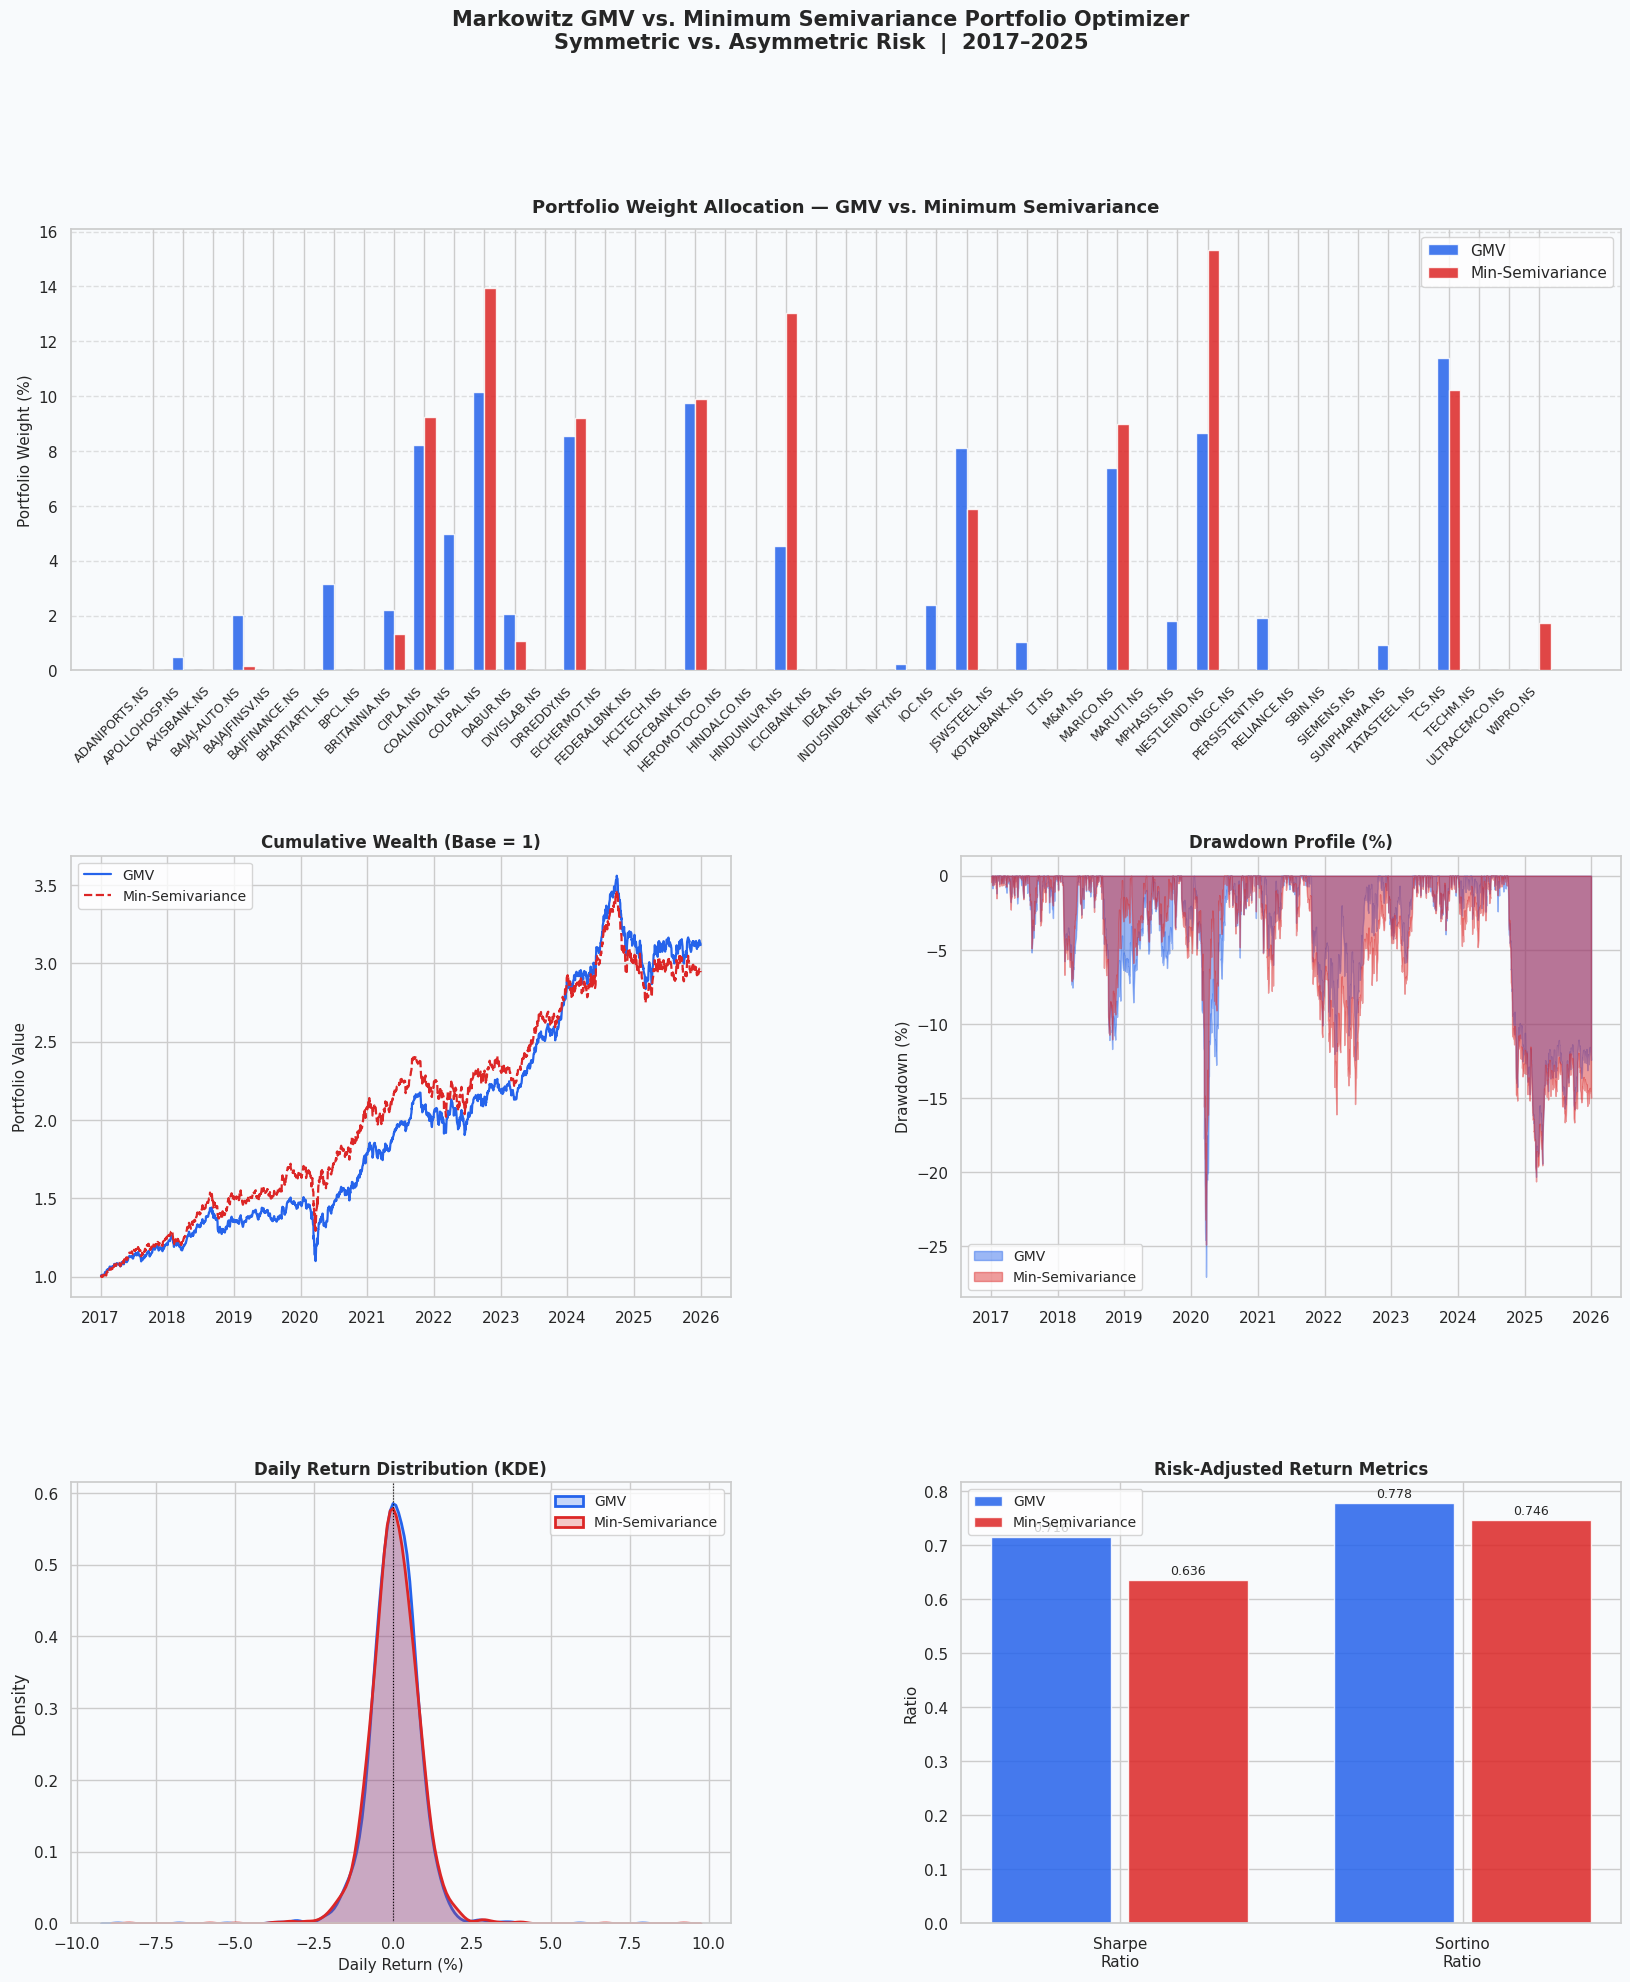

In [9]:
# VISUALISATION  (5-panel figure)

COLORS = {"gmv": "#2563EB", "semi": "#DC2626"}

sns.set_theme(style="whitegrid", palette="muted")
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("#F8FAFC")
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── A: Weight Comparison ──────────────────────────────────────
ax1  = fig.add_subplot(gs[0, :])
x, bw = np.arange(N), 0.38
ax1.bar(x - bw/2, w_gmv_val  * 100, bw, label="GMV",              color=COLORS["gmv"],  alpha=0.85, zorder=3)
ax1.bar(x + bw/2, w_semi_val * 100, bw, label="Min-Semivariance", color=COLORS["semi"], alpha=0.85, zorder=3)
ax1.set_xticks(x)
ax1.set_xticklabels(tickers, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Portfolio Weight (%)", fontsize=11)
ax1.set_title("Portfolio Weight Allocation — GMV vs. Minimum Semivariance",
              fontsize=13, fontweight="bold", pad=12)
ax1.legend(fontsize=11)
ax1.set_facecolor("#F8FAFC")
ax1.yaxis.grid(True, linestyle="--", alpha=0.6)

# ── B: Cumulative Wealth ──────────────────────────────────────
ax2       = fig.add_subplot(gs[1, 0])
cum_gmv   = np.cumprod(1 + R @ w_gmv_val)
cum_semi  = np.cumprod(1 + R @ w_semi_val)
plot_dates = prices_clean.index[-T:]
ax2.plot(plot_dates, cum_gmv,  color=COLORS["gmv"],  lw=1.6, label="GMV")
ax2.plot(plot_dates, cum_semi, color=COLORS["semi"], lw=1.6, label="Min-Semivariance", linestyle="--")
ax2.set_title("Cumulative Wealth (Base = 1)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Portfolio Value", fontsize=11)
ax2.legend(fontsize=10)
ax2.set_facecolor("#F8FAFC")

# ── C: Drawdown ───────────────────────────────────────────────
ax3    = fig.add_subplot(gs[1, 1])
dd_gmv  = cum_gmv  / np.maximum.accumulate(cum_gmv)  - 1
dd_semi = cum_semi / np.maximum.accumulate(cum_semi) - 1
ax3.fill_between(plot_dates, dd_gmv  * 100, alpha=0.45, color=COLORS["gmv"],  label="GMV")
ax3.fill_between(plot_dates, dd_semi * 100, alpha=0.45, color=COLORS["semi"], label="Min-Semivariance")
ax3.set_title("Drawdown Profile (%)", fontsize=12, fontweight="bold")
ax3.set_ylabel("Drawdown (%)", fontsize=11)
ax3.legend(fontsize=10)
ax3.set_facecolor("#F8FAFC")

# ── D: Return Distribution (KDE) ─────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
sns.kdeplot(R @ w_gmv_val  * 100, ax=ax4, color=COLORS["gmv"],  lw=2,
            label="GMV",              fill=True, alpha=0.25)
sns.kdeplot(R @ w_semi_val * 100, ax=ax4, color=COLORS["semi"], lw=2,
            label="Min-Semivariance", fill=True, alpha=0.25)
ax4.axvline(0, color="black", lw=0.8, linestyle=":")
ax4.set_title("Daily Return Distribution (KDE)", fontsize=12, fontweight="bold")
ax4.set_xlabel("Daily Return (%)", fontsize=11)
ax4.legend(fontsize=10)
ax4.set_facecolor("#F8FAFC")

# ── E: Sharpe & Sortino Comparison ───────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
metric_names = ["Sharpe\nRatio", "Sortino\nRatio"]
gmv_vals     = [m_gmv["sharpe"],  m_gmv["sortino"]]
semi_vals    = [m_semi["sharpe"], m_semi["sortino"]]
xm = np.arange(len(metric_names))
b1 = ax5.bar(xm - 0.2, gmv_vals,  0.35, label="GMV",              color=COLORS["gmv"],  alpha=0.85)
b2 = ax5.bar(xm + 0.2, semi_vals, 0.35, label="Min-Semivariance", color=COLORS["semi"], alpha=0.85)
ax5.set_xticks(xm)
ax5.set_xticklabels(metric_names, fontsize=11)
ax5.set_title("Risk-Adjusted Return Metrics", fontsize=12, fontweight="bold")
ax5.set_ylabel("Ratio", fontsize=11)
ax5.legend(fontsize=10)
ax5.set_facecolor("#F8FAFC")
for rect, v in zip(list(b1) + list(b2), gmv_vals + semi_vals):
    ax5.text(rect.get_x() + rect.get_width() / 2,
             rect.get_height() + 0.005, f"{v:.3f}",
             ha="center", va="bottom", fontsize=9)

fig.suptitle(
    "Markowitz GMV vs. Minimum Semivariance Portfolio Optimizer\n"
    f"Symmetric vs. Asymmetric Risk  |  {prices_clean.index[0].year}–{prices_clean.index[-1].year}",
    fontsize=15, fontweight="bold", y=0.98,
)

plt.show()

